# KNN

In [2]:
from sklearn.svm import SVC
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
import pandas as pd
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score

import joblib
import optuna

import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
seed = 42

In [4]:
dataset = pd.read_csv("./datasets/thyroid0387_balanced.data", sep = ";", index_col="Unnamed: 0")

In [5]:
numeric_col = dataset.select_dtypes(include = ["int64", "float64"]).columns

scaler = StandardScaler()
dataset[numeric_col] = scaler.fit_transform(dataset[numeric_col])

In [6]:
dataset["diagnosis_group"].value_counts()

diagnosis_group
normal                   6446
misc                     6446
hypothyroid              6446
hyperthyroid             6446
binding_protein          6446
replacement_therapy      6446
general_health           6446
antithyroid_treatment    6446
Name: count, dtype: int64

In [7]:
dataset.isnull().sum().sort_values(ascending=False)


age                          0
sex_M                        0
ref_other                    0
ref_WEST                     0
ref_SVI                      0
ref_SVHD                     0
ref_SVHC                     0
ref_STMW                     0
TBG_value                    0
FTI_value                    0
T4U_value                    0
TT4_value                    0
T3_value                     0
TSH_value                    0
psych                        0
on_thyroxine                 0
hypopituitary                0
tumor                        0
goitre                       0
lithium                      0
query_hyperthyroid           0
query_hypothyroid            0
I131_treatment               0
thyroid_surgery              0
pregnant                     0
sick                         0
on_antithyroid_medication    0
query_on_thyroxine           0
diagnosis_group              0
dtype: int64

In [8]:
dataset.dropna()["diagnosis_group"].value_counts()

diagnosis_group
normal                   6446
misc                     6446
hypothyroid              6446
hyperthyroid             6446
binding_protein          6446
replacement_therapy      6446
general_health           6446
antithyroid_treatment    6446
Name: count, dtype: int64

In [9]:
dataset.head()

,age,on_thyroxine,query_on_thyroxine,on_antithyroid_medication,sick,pregnant,thyroid_surgery,I131_treatment,query_hypothyroid,query_hyperthyroid,...,T4U_value,FTI_value,TBG_value,ref_STMW,ref_SVHC,ref_SVHD,ref_SVI,ref_WEST,ref_other,diagnosis_group
0,-1.212790,False,False,False,False,False,False,False,True,False,...,-0.152529,-0.180795,1.046431,False,False,False,False,False,True,normal
1,-1.212790,False,False,False,False,False,False,False,False,False,...,-0.116076,0.181697,-0.825246,False,False,False,False,False,True,normal
2,-0.569556,False,False,False,False,False,False,False,False,True,...,-0.985641,0.014618,-2.723338,False,False,False,False,False,True,normal
3,-0.837570,False,False,False,False,False,False,False,False,False,...,0.072594,-0.236669,-0.069598,False,False,False,False,False,True,normal
4,-1.051981,False,False,False,False,False,False,False,False,False,...,-0.798453,-0.027173,1.699562,False,False,False,False,False,True,misc


In [10]:
dataset["diagnosis_group"].value_counts()

diagnosis_group
normal                   6446
misc                     6446
hypothyroid              6446
hyperthyroid             6446
binding_protein          6446
replacement_therapy      6446
general_health           6446
antithyroid_treatment    6446
Name: count, dtype: int64

In [11]:
label = LabelEncoder()
dataset["diagnosis_group"] = label.fit_transform(dataset["diagnosis_group"])

print(f"{dict(enumerate(label.classes_))}")

{0: 'antithyroid_treatment', 1: 'binding_protein', 2: 'general_health', 3: 'hyperthyroid', 4: 'hypothyroid', 5: 'misc', 6: 'normal', 7: 'replacement_therapy'}


In [12]:
x = dataset.drop(columns=["diagnosis_group"])
y = dataset["diagnosis_group"]

In [13]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.3, random_state = seed)

In [14]:
print(f"X train: {x_train.shape}\nX test: {x_test.shape}\nY train: {y_train.shape}\nY test: {y_test.shape}")

X train: (36097, 28)
X test: (15471, 28)
Y train: (36097,)
Y test: (15471,)


## Model

In [15]:
svm = SVC()
svm.fit(x_train, y_train)

y_pred = svm.predict(x_test)

## Model evaluation

Accuracy: 0.9897227070001939
F1 score: 0.9896814928635012


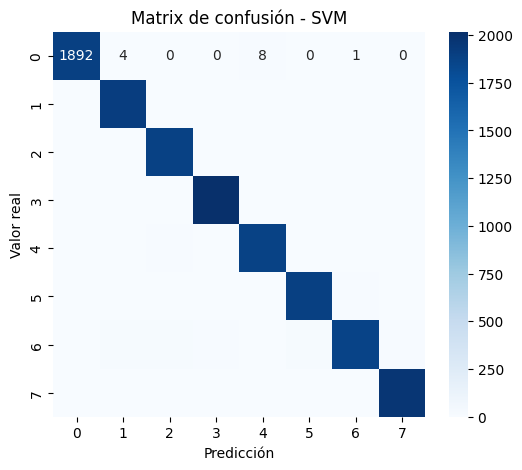

In [16]:
print(f"Accuracy: {accuracy_score(y_test, y_pred)}")
print(f"F1 score: {f1_score(y_test, y_pred, average = 'weighted')}")

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
            
plt.xlabel('Predicción')
plt.ylabel('Valor real')
plt.title('Matrix de confusión - SVM')
plt.show()


## Saving model

In [17]:
joblib.dump(svm, "./models_saved/svm.json")

['./models_saved/svm.json']

## Bayesian optimization

Function that will be used during the optimization

In [20]:
def objective(trial):
    params = {
        "C": trial.suggest_float("C", 1e-3, 50, log=True),
        "kernel": trial.suggest_categorical("kernel", ["linear", "poly", "rbf", "sigmoid"]),
        "gamma": trial.suggest_categorical("gamma", ["scale", "auto"]),
        "degree": trial.suggest_int("degree", 2, 8),
    }

    model = SVC(**params)
    model.fit(x_train, y_train)

    y_pred = model.predict(x_test)

    return f1_score(y_test, y_pred, average = "weighted")

Optimization process

In [21]:
optimization = optuna.create_study(direction = "maximize")
optimization.optimize(objective, n_trials = 100)

[I 2025-04-18 21:03:16,654] A new study created in memory with name: no-name-74eba76b-fae4-449c-a408-e553ebf7b21c
[I 2025-04-18 21:05:48,417] Trial 0 finished with value: 0.8210516790280645 and parameters: {'C': 0.001780788558321851, 'kernel': 'rbf', 'gamma': 'scale', 'degree': 7}. Best is trial 0 with value: 0.8210516790280645.
[I 2025-04-18 21:06:56,102] Trial 1 finished with value: 0.060618524644877984 and parameters: {'C': 0.008413316853614418, 'kernel': 'poly', 'gamma': 'auto', 'degree': 8}. Best is trial 0 with value: 0.8210516790280645.
[I 2025-04-18 21:07:15,547] Trial 2 finished with value: 0.8615244996787925 and parameters: {'C': 0.5933612126974377, 'kernel': 'poly', 'gamma': 'scale', 'degree': 7}. Best is trial 2 with value: 0.8615244996787925.
[I 2025-04-18 21:07:17,813] Trial 3 finished with value: 0.9918959190352163 and parameters: {'C': 6.62119166283412, 'kernel': 'poly', 'gamma': 'scale', 'degree': 3}. Best is trial 3 with value: 0.9918959190352163.
[I 2025-04-18 21:08:

In [22]:
print(f"Best parameters: {optimization.best_params}")

Best parameters: {'C': 22.332679578002093, 'kernel': 'rbf', 'gamma': 'scale', 'degree': 2}


In [23]:
svm = SVC(**optimization.best_params)
svm.fit(x_train, y_train)

y_pred = svm.predict(x_test)

In [24]:
print(f"Accuracy: {accuracy_score(y_test, y_pred)}")
print(f"F1 score: {f1_score(y_test, y_pred, average = 'weighted')}")

Accuracy: 0.9952168573460022
F1 score: 0.9952101255910648


In [25]:
joblib.dump(svm, "./models_saved/svm_opt.json")

['./models_saved/svm_opt.json']